![Logo Curso](../assets/LogoCurso_gemini.png)

# MÓDULO 10: Acceso a Datos Repositoriales vía APIs y Protocolo OAI-PMH (Digital.CSIC)

**Curso:** Python para Ciencia Abierta (CSIC)  
**Autor:** Gustavo Liñán Cembrano  
**Fechas:** 5 a 8 de Octubre de 2026  
**Tiempo Estimado de Impartición:** 1 hora  
**Módulo:** 10 - Web APIs, REST Architecture, OAI-PMH Protocol, XML Parsing with BeautifulSoup & Digital.CSIC Harvesting  


[Uso de APIs](../doc/PDFS/SLIDES/5_Uso_de_APIs.pdf)


---

## 1. Objetivos de Aprendizaje

- **APIs Web y Arquitectura REST vs. OAI-PMH:** Comprender la diferencia entre las APIs RESTful modernas (JSON, endpoints por recurso) y el protocolo de recolección de metadatos académicos **OAI-PMH** (XML, verbos HTTP).


- **Acceso a Repositorios Institucionales:** Explorar cómo **Digital.CSIC** (basado en la plataforma **DSpace**) expone metadatos científicos normalizados en esquema **Dublin Core** (`oai_dc`).


- **Verbos OAI-PMH:** Dominar los verbos fundamentales (`Identify`, `ListMetadataFormats`, `ListIdentifiers`, `ListRecords`, `GetRecord`) y el manejo de paginación con `resumptionToken`.


- **Parseo de XML con BeautifulSoup:** Utilizar `requests` y `BeautifulSoup(response.content, 'xml')` para la inspección y extracción de etiquetas XML y namespaces.


- **Búsqueda y Extracción Programática:** Desarrollar scripts en Python para listar, filtrar por palabras clave, extraer autores (`dc:creator`), títulos (`dc:title`) y handles institucionales (`10261/...`).


- **Integración con la Librería del Curso (`lib/digital_csic.py`):** Conectar los conceptos teóricos y prácticos aprendidos con las funciones automatizadas del paquete de utilidades del curso.


## 2. Fundamentos Teóricos: APIs REST vs. Protocolo OAI-PMH

### ¿Qué es una API RESTful?
Una **API REST** (*Representational State Transfer*) es una interfaz de programación de aplicaciones basada en los principios de la web:
- **Recursos Identificados por URIs:** Cada entidad (usuario, publicación, proyecto) tiene una dirección de red propia.
- **Métodos HTTP:** Operaciones CRUD mediante `GET` (lectura), `POST` (creación), `PUT`/`PATCH` (actualización) y `DELETE` (eliminación).
- **Formatos Ligeros:** Respuestas estandarizadas habitualmente en formato **JSON**.
- **Autenticación y Control:** Autenticación por Tokens (**API Keys**, **OAuth 2.0**) y políticas de límite de frecuencia (*rate limiting*).

---

### ¿Qué es el Protocolo OAI-PMH?
**OAI-PMH** (*Open Archives Initiative — Protocol for Metadata Harvesting*) es un estándar internacional diseñado específicamente para la **recolección masiva e interoperable de metadatos** entre repositorios académicos e instituciones de investigación.

- **Transporte y Formato:** Funciona sobre HTTP `GET`/`POST` y responde en formato estructurado **XML**.
- **Enfoque en Metadatos:** Recolecta fichas bibliográficas normalizadas (título, autor, fecha, identificador Handle/DOI), no archivos binarios pesados (PDFs/ZIPs).
- **Esquema Dublin Core (`oai_dc`):** Todos los repositorios compatibles con OAI-PMH deben soportar por mandato el esquema [Dublin Core](https://www.dublincore.org/specifications/dublin-core/dces/).

---

### 📊 Cuadro Comparativo: REST API vs. OAI-PMH

| Característica | API REST Modernas | Protocolo OAI-PMH |
| :--- | :--- | :--- |
| **Propósito Principal** | Interacción transaccional y consultas específicas. | Recolección masiva de metadatos (*Harvesting*). |
| **Formato de Respuesta** | Principalmente **JSON** (o XML/YAML). | Estrictamente **XML** estructurado con Namespaces. |
| **Parámetros de Consulta** | Filtros arbitrarios (`?q=ciencia&page=1`). | Verbos estandarizados (`Identify`, `ListRecords`). |
| **Paginación** | Parámetros `page`, `offset`, `limit`. | Controlada por el servidor mediante `resumptionToken`. |
| **Autenticación** | API Key, Bearer Token, OAuth. | Generalmente abierto (Acceso público de Ciencia Abierta). |


## 3. Esquema de Metadatos Dublin Core (`oai_dc`)

El protocolo OAI-PMH exige que todo repositorio exponga sus metadatos al menos en el formato **Dublin Core** (`oai_dc`). Este estándar define elementos fundamentales de metadatos:

- `dc:title` $\rightarrow$ Título de la obra o artículo científico.
- `dc:creator` $\rightarrow$ Autor(es) o entidad creadora.
- `dc:date` $\rightarrow$ Fecha de publicación o depósito.
- `dc:identifier` $\rightarrow$ Identificador único (Handle `10261/...`, DOI, URI).
- `dc:description` $\rightarrow$ Resumen (*abstract*) o descripción de la investigación.
- `dc:subject` $\rightarrow$ Palabras clave, materias o descriptores temáticos.
- `dc:publisher` $\rightarrow$ Editorial o institución editora.
- `dc:type` $\rightarrow$ Tipo de recurso (artículo, tesis, conjunto de datos, patente).
- `dc:language` $\rightarrow$ Idioma del documento (ej. `es`, `en`).


## 4. Primer Acceso a Digital.CSIC: Verbo `Identify`

**Digital.CSIC** expone su servicio OAI-PMH en la dirección base:
👉 `https://digital.csic.es/dspace-oai/request`

A continuación realizamos una consulta inicial con el verbo **`Identify`**, que devuelve los metadatos generales del repositorio.


In [1]:

# Importación de librerías para comunicación HTTP, parseo XML y ruta de sistema

import os                       # Gestión de archivos y variables de entorno del sistema operativo
import sys                      # Configuración del entorno de ejecución y rutas de Python
import requests                 # Peticiones HTTP para consultar APIs y servidores web (Digital.CSIC)
from bs4 import BeautifulSoup   # Parseo y extracción de datos en documentos XML y HTML




In [2]:
# Añadir el directorio raíz del proyecto a sys.path para acceder al paquete lib/
root_path = os.path.abspath("..") if os.path.exists("../lib") else os.path.abspath(".")
if root_path not in sys.path:
    sys.path.append(root_path)

import lib.digital_csic as dcsic
from lib.mylib import linea as linea
# Ruta base flexible para el directorio DATASETS
datasets_dir = "../DATASETS" if os.path.exists("../DATASETS") else "DATASETS"
linea()
print(f"Librería digital_csic cargada correctamente.")
print(f"Directorio de datos activo: {datasets_dir}")
linea()


****************************************************************************************************
Librería digital_csic cargada correctamente.
Directorio de datos activo: ../DATASETS
****************************************************************************************************


💡 ¿Qué responde un servidor al que se hace una consulta?

Cada vez que tu código en Python envía una petición a un servidor web o API (como el servidor OAI-PMH de Digital.CSIC), el servidor responde con un Código de Estado HTTP (Status Code) numérico:

- 200 OK (Éxito): El servidor entendió la petición, la procesó correctamente y devuelve los datos solicitados (el XML/HTML o JSON).

- 404 Not Found (Error del cliente): La URL no existe o la página no fue encontrada.

- 403 Forbidden (Error del cliente): No tienes permisos o token válido para acceder.

- 500 Internal Server Error (Error del servidor): El servidor del CSIC tuvo un fallo interno.

In [3]:


# Endpoint base del servicio OAI-PMH de Digital.CSIC
base_url = "https://digital.csic.es/dspace-oai/request"

# Parámetros HTTP: Verbo Identify (Información general del repositorio)
params = {"verb": "Identify"}

# Realizamos la petición HTTP GET al servidor de Digital.CSIC
response = requests.get(base_url, params=params)

if response.status_code == 200:
    
    # Parseamos la respuesta XML utilizando BeautifulSoup con el motor 'xml'
    soup = BeautifulSoup(response.content, "xml")
    
    repo_name = soup.find("repositoryName").text if soup.find("repositoryName") else "No disponible"

    url_base = soup.find("baseURL").text if soup.find("baseURL") else "No disponible"
    
    proto_ver = soup.find("protocolVersion").text if soup.find("protocolVersion") else "No disponible"
    
    admin_email = soup.find("adminEmail").text.strip() if soup.find("adminEmail") else "No disponible"
    
    linea()
    print(f"🏛️  Nombre del Repositorio: {repo_name}")
    linea()
    print(f"🔗  Base URL OAI-PMH: {url_base}")
    linea()
    print(f"📌  Versión Protocolo OAI-PMH: {proto_ver}")
    linea()
    print(f"📧  Email del Administrador: {admin_email}")
    linea()
else:
    print(f"❌ Error al consultar el endpoint OAI-PMH. Código HTTP: {response.status_code}")


****************************************************************************************************
🏛️  Nombre del Repositorio: DIGITAL.CSIC
****************************************************************************************************
🔗  Base URL OAI-PMH: https://digital.csic.es/dspace-oai/request
****************************************************************************************************
📌  Versión Protocolo OAI-PMH: 2.0
****************************************************************************************************
📧  Email del Administrador: julio.pemau@bib.csic.es
****************************************************************************************************


## 5. Recuento Total de Registros y Paginación (`ListRecords` + `resumptionToken`)

Para consultar el volumen total de publicaciones custodiadas en Digital.CSIC, utilizamos el verbo **`ListRecords`** especificando el formato `oai_dc`. La respuesta incluye la etiqueta `<resumptionToken>` con el atributo `completeListSize`.


In [4]:
# Petición para listar registros y consultar el volumen total en Digital.CSIC
from datetime import datetime
import time

params_records = {
    "verb": "ListRecords",
    "metadataPrefix": "oai_dc"
}

# Breve pausa de cortesía en peticiones de red
time.sleep(1)

resp_records = requests.get(base_url, params=params_records)

if resp_records.status_code == 200:
    soup_records = BeautifulSoup(resp_records.content, "xml")
    
    # Inspeccionar las primeras 5 líneas del texto XML recibido
    lineas_xml = soup_records.text.splitlines()
    print("📜 Inspección de las primeras 5 líneas del XML recibido:")
    for idx, linea_text in enumerate(lineas_xml[:5], start=1):
        print(f"  [{idx}]: {linea_text}")
    
    # Extracción del tag resumptionToken (contiene el atributo completeListSize)
    resumption_tag = soup_records.find("resumptionToken")
    
    if resumption_tag and resumption_tag.has_attr("completeListSize"):
        total_records = int(resumption_tag["completeListSize"])
    else:
        records_page = soup_records.find_all("record")
        total_records = len(records_page)
        
    fecha_hoy = datetime.now().strftime("%d/%m/%Y")
    linea()
    print(f"📊 A fecha {fecha_hoy}, el número total de registros en Digital.CSIC es: {total_records:,}")
    linea()
else:
    print(f"❌ Error HTTP {resp_records.status_code} al solicitar ListRecords.")


📜 Inspección de las primeras 5 líneas del XML recibido:
  [1]: 2026-10-07T11:39:07Zhttps://digital.csic.es/dspace-oai/requestoai:digital.csic.es:10261/13992021-12-27T15:35:21Zcom_10261_25com_10261_1col_10261_278
  [2]: An analysis of the Sargasso Sea resource and the consequences for database composition
  [3]: Tress, Michael L.
  [4]: Cozzetto, Domenico
  [5]: Tramontano, Anna
****************************************************************************************************
📊 A fecha 07/10/2026, el número total de registros en Digital.CSIC es: 414,478
****************************************************************************************************


## 6. Búsqueda y Filtrado Programático por Palabras Clave

Dado que el protocolo OAI-PMH no ofrece un buscador textual por palabra clave en la URL, procesamos en memoria las etiquetas `<record>` devueltas, inspeccionando `dc:title`, `dc:creator` e `identifier`.


In [5]:
# Extracción de metadatos y filtrado por palabra clave en títulos
registros = soup_records.find_all("record")
keyword = "csic"

ids_list = []
authors_list = []
titles_list = []

for r in registros:
    titulo_tag = r.find("dc:title")
    identifier_tag = r.find("identifier")
    autores_tags = r.find_all("dc:creator")
    
    if titulo_tag and identifier_tag and autores_tags:
        titulo_text = titulo_tag.text.strip()
        
        # Filtrar si la palabra clave está en el título (case-insensitive)
        if keyword in titulo_text.lower():
            # Extraer Handle (ej. oai:digital.csic.es:10261/1400 -> 10261/1400)
            oai_id = identifier_tag.text.strip()
            handle = oai_id.split(":")[-1] if ":" in oai_id else oai_id
            
            # Formatear lista de autores con sus índices [1], [2]
            nombres_autores = [a.text.strip() for a in autores_tags]
            autores_str = ", ".join([f"{nom}[{i+1}]" for i, nom in enumerate(nombres_autores)])
            
            ids_list.append(handle)
            authors_list.append(autores_str)
            titles_list.append(titulo_text)

linea()
print(f"🔎 Registros encontrados con la palabra '{keyword}' en el primer lote: {len(ids_list)}")
linea()

# Iteración paralela con zip y enumerate
for idx, (h, aut, tit) in enumerate(zip(ids_list, authors_list, titles_list), start=1):
    print(f"[{idx}] Handle: {h}")
    print(f"    Autores: {aut}")
    print(f"    Título:  {tit}")
    linea()


****************************************************************************************************
🔎 Registros encontrados con la palabra 'csic' en el primer lote: 3
****************************************************************************************************
[1] Handle: 10261/1400
    Autores: Ponsati Obiols, Agnès[1], Baquero Arribas, Mercedes[2]
    Título:  Establishing digital collections in a scientific research library network: part one of a case study from CSIC, Madrid, Spain
****************************************************************************************************
[2] Handle: 10261/1411
    Autores: Ponsati Obiols, Agnès[1], Baquero Arribas, Mercedes[2]
    Título:  Establishing digital collections in a research library network: part one of a case study from CSIC, Madrid, Spain
****************************************************************************************************
[3] Handle: 10261/1449
    Autores: Ponsati Obiols, Agnès[1]
    Título:  Un año d

## 7. Integración con la Librería del Curso (`lib/digital_csic.py`)

La librería del curso encapsula estas peticiones OAI-PMH en funciones reutilizables. A continuación verificamos cómo `dcsic.fetch_digital_csic_record()` consulta el servidor en tiempo real.


In [6]:
# Demostración del uso de la librería personalizada lib/digital_csic.py
import lib.digital_csic as dcsic
from lib.mylib import linea

# Consultar un Handle específico en Digital.CSIC mediante la librería
sample_handle = "10261/403880"

record_info = dcsic.fetch_digital_csic_record(sample_handle)

# Comprobación de existencia/validez (devuelve dict si existe, None si no)
es_valido = record_info is not None

linea()
print(f"📚 Registro recuperado vía lib.digital_csic:")
print(f" - Handle:      {sample_handle}")
print(f" - ¿Existe?:    {es_valido}")

if record_info:
    print(f" - Título:      {record_info.get('title')}")
    print(f" - Autores:     {record_info.get('authors')}")
    print(f" - Año:         {record_info.get('year')}")
    print(f" - Fuente:      {record_info.get('journal')}")
    print(f" - DOI:         {record_info.get('doi')}")
linea()


****************************************************************************************************
📚 Registro recuperado vía lib.digital_csic:
 - Handle:      10261/403880
 - ¿Existe?:    True
 - Título:      Introducing the UNREST project: antagonistic, cosmopolitan and agonistic memory in Europe today. Workshop Brussels 2016
 - Autores:     Hansen, Hans Lauge
 - Año:         2025
 - Fuente:      Digital.CSIC
 - DOI:         10.13039/501100000780
****************************************************************************************************


In [7]:
# Demostración del uso de la librería personalizada lib/digital_csic.py
import lib.digital_csic as dcsic
from lib.mylib import linea
import pandas as pd

datasets_dir = "../DATASETS" if os.path.exists("../DATASETS") else "DATASETS"

handles_file = os.path.join(datasets_dir, "asistentes_handles.csv")

alumnos_handles = dcsic.load_handles_from_file(handles_file)

for handle in alumnos_handles:
    record_info = dcsic.fetch_digital_csic_record(handle)

    # Comprobación de existencia/validez (devuelve dict si existe, None si no)
    es_valido = record_info is not None

    linea()
    print(f"📚 Registro recuperado vía lib.digital_csic:")
    print(f" - Handle:      {handle}")
    print(f" - ¿Existe?:    {es_valido}")

    if es_valido:
        print(f" - Título:      {record_info.get('title')}")
        print(f" - Autores:     {record_info.get('authors')}")
        print(f" - Año:         {record_info.get('year')}")
        print(f" - Fuente:      {record_info.get('journal')}")
        print(f" - DOI:         {record_info.get('doi')}")
    linea()

13:49:35 [INFO] Cargados 22 Handles válidos desde '../DATASETS/asistentes_handles.csv'


****************************************************************************************************
📚 Registro recuperado vía lib.digital_csic:
 - Handle:      10261/443637
 - ¿Existe?:    True
 - Título:      Screening of Stable Reference Genes in Solea senegalensis Juveniles for Nervous Necrosis Virus (NNV) Vaccination Assays
 - Autores:     Vázquez-Salgado, Lucía, López-Vázquez, Carmen, Bandín, Isabel, Souto, Sandra
 - Año:         2026
 - Fuente:      Multidisciplinary Digital Publishing Institute
 - DOI:         10.3390/vetsci13080790
****************************************************************************************************
****************************************************************************************************
📚 Registro recuperado vía lib.digital_csic:
 - Handle:      10261/440159
 - ¿Existe?:    True
 - Título:      Las redes alimentarias sostenibles como cadenas de valores para la transición agroecológica y alimentaria
 - Autores:     Sanz Cañada, Javier

### 📄 Generación de Citas Bibliográficas con `GeneraAPA()`
La librería `lib/digital_csic.py` proporciona la función **`GeneraAPA(response)`**, diseñada para extraer automáticamente los metadatos bibliográficos de un registro obtenido desde el servidor OAI-PMH de **Digital.CSIC** y formatearlos en una referencia estructurada.
#### 📌 Funcionamiento y Parámetros
- **Función:** `dcsic.GeneraAPA(response)`
- **Parámetro `response`:** Recibe la respuesta de `requests.get()` al consultar un registro mediante el verbo `GetRecord` (`metadataPrefix="oai_dc"`). *(También acepta cadenas de texto XML o instancias de `BeautifulSoup`)*.
- **Información extraída:**
  1. **Autores (`dc:creator`):** Une la lista de autores separados por comas.
  2. **Título (`dc:title`):** Extrae el título de la publicación científica.
  3. **Revista / Fuente (`identifier`):** Identifica heurísticamente la cita de la fuente.
  4. **DOI:** Extrae la dirección `https://doi.org/...` o el prefijo `10.XXXX/...`.
  5. **Handle:** Obtiene la dirección permanente `http://hdl.handle.net/10261/...`.


In [8]:
from lib.digital_csic import GeneraAPA as GeneraAPA
# 1. Petición OAI-PMH GetRecord a Digital.CSIC
base_url = "https://digital.csic.es/dspace-oai/request"
params = {
    "verb": "GetRecord",
    "metadataPrefix": "oai_dc",
    "identifier": f"oai:digital.csic.es:{sample_handle}"
}

response = requests.get(base_url, params=params, timeout=10)

# 2. Generar cita formateada llamando a la librería
cita_apa = GeneraAPA(response)

linea()
print("Cita Bibliográfica (Formato APA / Digital.CSIC):")
print(cita_apa)
linea()


****************************************************************************************************
Cita Bibliográfica (Formato APA / Digital.CSIC):
Hansen, H. L. (2025). Introducing the UNREST project: antagonistic, cosmopolitan and agonistic memory in Europe today. Workshop Brussels 2016. http://dx.doi.org/10.13039/501100000780
****************************************************************************************************


## 🌐 Ejercicio Avanzado: Extracción Masiva del Catálogo Completo de handles de Digital.CSIC (OAI-PMH)
En esta sección utilizaremos el protocolo **OAI-PMH** (*Open Archives Initiative Protocol for Metadata Harvesting*) para extraer la lista completa de identificadores **Handle** alojados en el repositorio institucional **Digital.CSIC**.


### 💡 Conceptos Clave de la API OAI-PMH


1. **Verbo `ListIdentifiers`:** A diferencia de `ListRecords` (que devuelve todo el contenido XML de cada documento), `ListIdentifiers` extrae únicamente las cabeceras (`<header>`) con los identificadores globales y sus fechas de modificación. Es el método más ligero y eficiente para indexar repositorios de gran volumen.


2. **Paginación con `resumptionToken`:** Los servidores OAI-PMH dividen las respuestas en páginas (habitualmente de 100 en 100 registros). Al final de cada respuesta XML, el servidor incluye una etiqueta `<resumptionToken>` que debemos enviar en la siguiente petición HTTP para obtener la página consecutiva.


3. **Buenas Prácticas de Ciencia Abierta (Cortesía HTTP):** Al iterar sobre las **~410.000 entradas** del catálogo del CSIC, introducimos una pequeña pausa (`time.sleep(0.3)`) en cada petición para no sobrecargar el servidor institucional.


### 📁 Estructura del Archivo de Salida (`all_handles.csv`)
El resultado se exportará a la carpeta `DATASETS/FROM_DIGITALCSIC/all_handles.csv` con una estructura de columna única compatible con nuestras herramientas de curación de datos:


| `handle` |
| :--- |
| `10261/1399` |
| `10261/1400` |
| `10261/1401` |
| `...` |



> ⚠️ **Nota MUY IMPORTANTE:** Por defecto, la variable `MAX_RECORDS` está establecida en 1000 para no saturar al servidor, si quieres descargar todos los handles ponla en `None`.

In [11]:
import os
import time
import requests
import pandas as pd
import xml.etree.ElementTree as ET

# PARÁMETRO DE LÍMITE: Pon MAX_RECORDS = None para extraer los ~410.000 handles del catálogo completo

MAX_RECORDS = 5000  # Cambia a None para todos

# ==============================================================================
# 1. RUTAS ROBÚSTAS Y PARÁMETROS DE CONSULTA (OAI-PMH)
# ==============================================================================
OAI_BASE_URL = "https://digital.csic.es/dspace-oai/request"

# Resolución dinámica de la raíz del proyecto (funciona tanto dentro de NOTEBOOKS/ como en la raíz)
BASE_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(BASE_DIR, "..")) if os.path.basename(BASE_DIR) == "NOTEBOOKS" else BASE_DIR

OUTPUT_DIR = os.path.join(PROJECT_ROOT, "DATASETS", "FROM_DIGITALCSIC")
OUTPUT_CSV = os.path.join(OUTPUT_DIR, "all_handles.csv")

# Crear el directorio si no existe
os.makedirs(OUTPUT_DIR, exist_ok=True)



print("🌐 Conectando con el servidor OAI-PMH de Digital.CSIC...")
print(f"📁 Guardando resultado en: {OUTPUT_CSV}\n")

NS = {"oai": "http://www.openarchives.org/OAI/2.0/"}
handles_list = []
resumption_token = None
page_count = 0
total_available = None

session = requests.Session()
session.headers.update({"User-Agent": "CursoPythonCienciaAbierta/2.0 (CSIC)"})

# ==============================================================================
# 2. BUCLE DE EXTRACCIÓN DE HANDLES
# ==============================================================================
while True:
    page_count += 1
    
    if resumption_token is None:
        url = f"{OAI_BASE_URL}?verb=ListIdentifiers&metadataPrefix=oai_dc"
    else:
        url = f"{OAI_BASE_URL}?verb=ListIdentifiers&resumptionToken={resumption_token}"
        
    try:
        response = session.get(url, timeout=30)
        if response.status_code != 200:
            print(f"⚠️ Error HTTP {response.status_code} en pág. {page_count}. Reintentando...")
            time.sleep(3)
            continue
            
        root = ET.fromstring(response.content)
        
        # Tamaño total registrado en el repositorio
        token_elem = root.find(".//oai:resumptionToken", NS)
        if token_elem is not None and total_available is None:
            total_size_attr = token_elem.attrib.get("completeListSize")
            if total_size_attr:
                total_available = int(total_size_attr)
                print(f"📊 Catálogo total disponible en Digital.CSIC: {total_available:,} ítems\n")

        headers = root.findall(".//oai:header", NS)
        if not headers:
            print("ℹ️ No se devolvieron más registros.")
            break
            
        for h in headers:
            # Descartar elementos eliminados
            if h.attrib.get("status") == "deleted":
                continue
                
            ident_elem = h.find("oai:identifier", NS)
            if ident_elem is not None and ident_elem.text:
                oai_id = ident_elem.text.strip()
                # Extraer la parte del Handle (ej. "10261/22405")
                handle_id = oai_id.replace("oai:digital.csic.es:", "")
                handles_list.append({"handle": handle_id})

        current_total = len(handles_list)
        if total_available:
            pct = (current_total / total_available) * 100
            print(f"📥 Pág. {page_count:04d} | Extraídos: {current_total:,} / {total_available:,} ({pct:.1f}%)")
        else:
            print(f"📥 Pág. {page_count:04d} | Extraídos: {current_total:,} handles")

        # Verificar si alcanzamos el límite manual de prueba
        if MAX_RECORDS and current_total >= MAX_RECORDS:
            print(f"\n⏹️ Límite manual alcanzado (MAX_RECORDS = {MAX_RECORDS:,}).")
            break

        if token_elem is not None and token_elem.text:
            resumption_token = token_elem.text.strip()
            time.sleep(0.2)  # Pausa de cortesia hacia Digital.CSIC
        else:
            print("\n✅ Extracción completa finalizada.")
            break

    except Exception as e:
        print(f"❌ Error durante la llamada: {str(e)}. Reintentando en 5s...")
        time.sleep(5)

# ==============================================================================
# 3. EXPORTACIÓN A CSV CON COLUMNA ÚNICA ('handle')
# ==============================================================================
df_handles = pd.DataFrame(handles_list)

if MAX_RECORDS and len(df_handles) > MAX_RECORDS:
    df_handles = df_handles.iloc[:MAX_RECORDS]

df_handles.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")

print("\n" + "=" * 70)
print(f"💾 DATASET GUARDADO EN: {OUTPUT_CSV}")
print(f"📊 Total handles exportados: {len(df_handles):,}")
print("=" * 70)

# Mostrar vista previa de las primeras y ultimas 5 filas (columna única: 'handle')
df_handles.head()
df_handles.tail()


🌐 Conectando con el servidor OAI-PMH de Digital.CSIC...
📁 Guardando resultado en: /Users/linan/Desktop/RESEARCH/FORMACION/PYTHON_PARA_CIENCIA_ABIERTA_2/DATASETS/FROM_DIGITALCSIC/all_handles.csv

📊 Catálogo total disponible en Digital.CSIC: 414,478 ítems

📥 Pág. 0001 | Extraídos: 100 / 414,478 (0.0%)
📥 Pág. 0002 | Extraídos: 200 / 414,478 (0.0%)
📥 Pág. 0003 | Extraídos: 300 / 414,478 (0.1%)
📥 Pág. 0004 | Extraídos: 400 / 414,478 (0.1%)
📥 Pág. 0005 | Extraídos: 500 / 414,478 (0.1%)
📥 Pág. 0006 | Extraídos: 600 / 414,478 (0.1%)
📥 Pág. 0007 | Extraídos: 700 / 414,478 (0.2%)
📥 Pág. 0008 | Extraídos: 800 / 414,478 (0.2%)
📥 Pág. 0009 | Extraídos: 900 / 414,478 (0.2%)
📥 Pág. 0010 | Extraídos: 1,000 / 414,478 (0.2%)
📥 Pág. 0011 | Extraídos: 1,100 / 414,478 (0.3%)
📥 Pág. 0012 | Extraídos: 1,200 / 414,478 (0.3%)
📥 Pág. 0013 | Extraídos: 1,300 / 414,478 (0.3%)
📥 Pág. 0014 | Extraídos: 1,400 / 414,478 (0.3%)
📥 Pág. 0015 | Extraídos: 1,500 / 414,478 (0.4%)
📥 Pág. 0016 | Extraídos: 1,600 / 414,478 (0

,handle
4995,10261/7424
4996,10261/7425
4997,10261/7428
4998,10261/7426
4999,10261/7427


## 👻 Análisis de Cohesión: Detección de "Handles Fantasma" en Digital.CSIC

En los repositorios institucionales basados en DSpace como **Digital.CSIC**, a cada ítem o documento publicado se le asigna una secuencia numérica interna dentro del prefijo asignado (p. ej. `10261/1399`, `10261/1400`, `10261/1401`...).

Sin embargo, a lo largo del tiempo se producen huecos o **"handles fantasma"** por diversos motivos:


- **Registros eliminados o purgados** del sistema (*deleted records*).


- **Ítems privados, embargados o en proceso de revisión editorial** no indexados por la API OAI-PMH pública.


- **Reservas de secuencias** de la base de datos no consolidadas.

### 🧪 Metodología con Pandas y NumPy

1. **Lectura y Limpieza:** Leemos `all_handles.csv`, eliminamos el prefijo `10261/` y convertimos la columna a valores enteros.


2. **Rango Teórico con NumPy:** Determinamos el identificador mínimo y máximo del catálogo cargado y generamos una secuencia aritmética completa consecutiva con `np.arange(min, max + 1)`.


3. **Diferencia de Conjuntos:** Aplicamos la función `np.setdiff1d()` para comparar los IDs teóricos esperados frente a los IDs reales presentes en el CSV, identificando al instante todos los **handles fantasma**.


In [ ]:
import os
import pandas as pd
import numpy as np

# ==============================================================================
# 1. LECTURA DEL DATASET CON PANDAS
# ==============================================================================
# Comprobar la ruta del archivo (soporta DATASETS/FROM_DIGITAL_CSIC o DATASETS/FROM_DIGITALCSIC)
csv_path = os.path.join("..", "DATASETS", "FROM_DIGITAL_CSIC", "all_handles.csv")
if not os.path.exists(csv_path):
    csv_path = os.path.join("..", "DATASETS", "FROM_DIGITALCSIC", "all_handles.csv")
if not os.path.exists(csv_path):
    csv_path = os.path.join("DATASETS", "FROM_DIGITAL_CSIC", "all_handles.csv")

print(f"📖 Leyendo dataset desde: {csv_path}")
df_handles = pd.read_csv(csv_path)

# ==============================================================================
# 2. LIMPIEZA DEL PREFIJO '10261/' Y CONVERSIÓN A ENTEROS
# ==============================================================================
# Eliminar el prefijo "10261/", limpiar espacios y convertir a entero (int)
handles_limpios = (
    df_handles["handle"]
    .astype(str)
    .str.replace("10261/", "", regex=False)
    .str.strip()
)

# Convertir numéricamente eliminando posibles valores nulos o inválidos
ids_existentes = pd.to_numeric(handles_limpios, errors="coerce").dropna().astype(int).values

# ==============================================================================
# 3. CÁLCULO DEL MÍNIMO Y EL MÁXIMO
# ==============================================================================
min_id = int(ids_existentes.min())
max_id = int(ids_existentes.max())

print(f"\n🔢 Rango de IDs detectado en el dataset:")
print(f"   • Mínimo ID: {min_id}")
print(f"   • Máximo ID: {max_id}")

# ==============================================================================
# 4. GENERACIÓN DE SECUENCIA CONTINUA CON NUMPY (np.arange)
# ==============================================================================
# Crear array de NumPy con la secuencia matemática completa (min -> max inclusivo)
rango_esperado = np.arange(min_id, max_id + 1)
total_esperados = len(rango_esperado)

# ==============================================================================
# 5. DETECCIÓN DE HANDLES FANTASMA (DIFERENCIA DE CONJUNTOS DE NUMPY)
# ==============================================================================
# Obtenemos los números que están en el rango esperado pero NO en la lista real
handles_fantasma_ids = np.setdiff1d(rango_esperado, ids_existentes)
total_fantasmas = len(handles_fantasma_ids)

# Reconstruir el formato oficial "10261/XXXX" para los handles fantasma
handles_fantasma = [f"10261/{h_id}" for h_id in handles_fantasma_ids]

# ==============================================================================
# 📊 RESUMEN Y MUESTRA DE RESULTADOS
# ==============================================================================
pct_fantasmas = (total_fantasmas / total_esperados) * 100

print("\n" + "=" * 70)
print("📊 INFORME DE DENSIDAD DEL REPOSITORIO (HANDLES FANTASMA)")
print("=" * 70)
print(f"✅ Handles reales presentes en el CSV: {len(ids_existentes):,}")
print(f"📐 Total teórico esperado (min a max):  {total_esperados:,}")
print(f"👻 Handles Fantasma (huecos/borrados):  {total_fantasmas:,} ({pct_fantasmas:.2f}% del rango)")
print("=" * 70)


## 📉 Visualización Gráfica de la Acumulación de Huecos (*Gaps*)

Para entender cómo se distribuyen y acumulan los **handles fantasma** a lo largo del catálogo, representamos gráficamente el identificador de cada documento frente a su posición ordinal en el dataset:

1. **Normalización a cero ($y = \text{ID} - \text{ID}_{\min}$):** Restamos el ID inicial ($\text{ID}_{\min}$) a todos los handles para que el eje vertical comience en $0$.
2. **Línea Teórica Ideal (Gris Discontinua):** Si no existiese ningún hueco ni borrado y la secuencia fuera 100% continua, los IDs avanzarían en una recta diagonal perfecta a 45° ($y = x$).
3. **Curva Real (Azul CSIC):** Muestra el avance real de los handles registrados. Cada salto vertical o desviación respecto a la recta ideal representa la **acumulación de handles borrados, privados o inaccesibles**.


/var/folders/f4/00yh35fj2n72dbqmsmlfghg00000gn/T/ipykernel_41069/89501155.py:67: UserWarning: Glyph 128123 (\N{GHOST}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/linan/Desktop/RESEARCH/FORMACION/PYTHON_PARA_CIENCIA_ABIERTA_2/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128123 (\N{GHOST}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


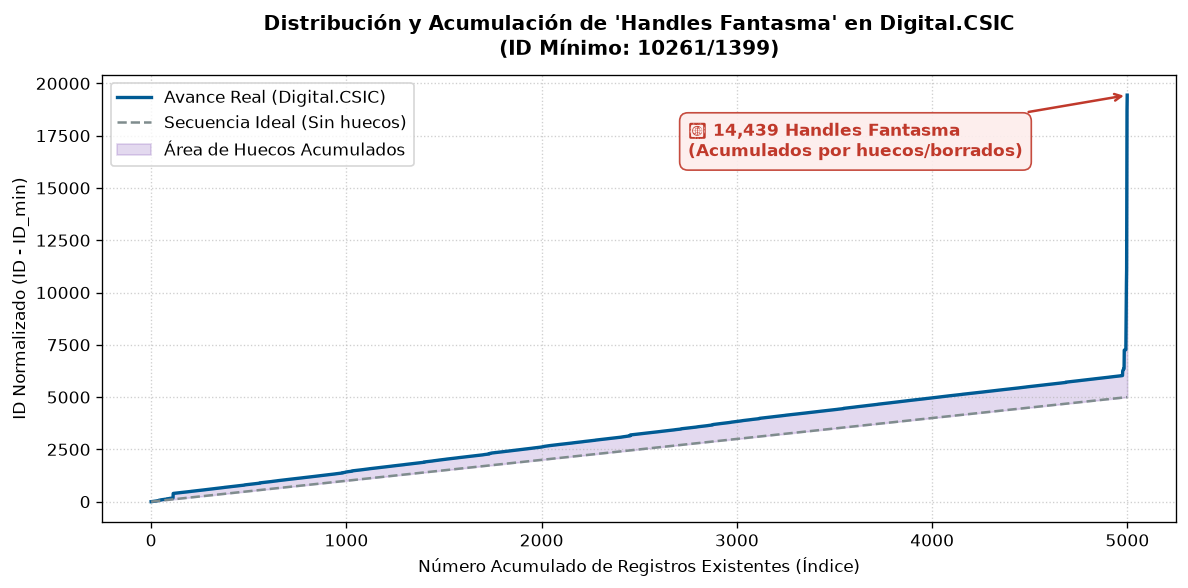

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. CARGA Y PREPARACIÓN DE DATOS
# ==============================================================================

csv_path = os.path.join("..", "DATASETS", "FROM_DIGITALCSIC", "all_handles.csv")

df = pd.read_csv(csv_path)

# Extraer IDs numéricos y ordenarlos de forma ascendente
handles_num = (
    pd.to_numeric(
        df["handle"].astype(str).str.replace("10261/", "", regex=False).str.strip(),
        errors="coerce"
    )
    .dropna()
    .astype(int)
    .sort_values()
    .values
)

min_id = handles_num.min()

# Normalizar resta de min_id para que el eje Y comience en 0
y_real = handles_num - min_id
x_indice = np.arange(len(y_real))  # Posición ordinal (0, 1, 2, 3...)

huecos_totales = y_real[-1] - x_indice[-1]

# ==============================================================================
# 2. CONSTRUCCIÓN DEL GRÁFICO CON MATPLOTLIB
# ==============================================================================
plt.figure(figsize=(10, 5), dpi=120)

# Curva Real (Aumento de handles en Digital.CSIC)
plt.plot(x_indice, y_real, color="#005B94", linewidth=2, label="Avance Real (Digital.CSIC)")

# Línea Teórica Ideal (Sin ningún hueco)
plt.plot(x_indice, x_indice, color="#7F8C8D", linestyle="--", linewidth=1.5, label="Secuencia Ideal (Sin huecos)")

# Sombreado del área entre la curva real e ideal (huecos acumulados)
plt.fill_between(x_indice, x_indice, y_real, color="#470094", alpha=0.15, label="Área de Huecos Acumulados")

# Personalización de títulos y etiquetas
plt.title(f"Distribución y Acumulación de 'Handles Fantasma' en Digital.CSIC\n(ID Mínimo: 10261/{min_id})", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Número Acumulado de Registros Existentes (Índice)", fontsize=10)
plt.ylabel("ID Normalizado (ID - ID_min)", fontsize=10)

# Anotación destacada del total de huecos
plt.annotate(
    f"👻 {huecos_totales:,} Handles Fantasma\n(Acumulados por huecos/borrados)",
    xy=(x_indice[-1], y_real[-1]),
    xytext=(x_indice[-1] * 0.55, y_real[-1] * 0.85),
    arrowprops=dict(arrowstyle="->", color="#C0392B", lw=1.5),
    fontsize=10,
    fontweight="bold",
    color="#C0392B",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#FDEDEC", edgecolor="#C0392B", alpha=0.9)
)

plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left", frameon=True)
plt.tight_layout()

plt.show()


---

### 🎬 Videopodcast Resumen del Módulo (10)

<div align="center">
  <video width="100%" style="max-width: 800px; border-radius: 8px; box-shadow: 0 4px 12px rgba(0,0,0,0.15);" controls>
    <source src="../assets/VIDEOPODCASTS/modulo_10.mp4" type="video/mp4">
    Tu navegador o entorno de Jupyter no soporta reproducción directa de vídeos HTML5.
  </video>
</div>

---

### 📝 Cuestionario de Auto-evaluación y Participación

¡Pon a prueba los conocimientos adquiridos en este módulo! Completa este breve cuestionario interactivo de 5 minutos en Google Forms:

👉 **[Cuestionario Módulo 10 en Google Forms](https://docs.google.com/forms/d/e/1FAIpQLSdyWStr15WSHLWUvLYNRi6BOTXpD_pojETZSUY2_3KESHLvfw/viewform?usp=sharing&ouid=101670006760862697598)**

---

### 🎧 Tutor Virtual & Libreta de Estudio (Google NotebookLM)

¿Quieres escuchar el resumen conversacional en audio de este módulo o resolver dudas con el tutor virtual del curso?

👉 **[Acceder al Espacio de Estudio Interactivo en NotebookLM](https://notebook.google.com/notebook/d76ad7db-e258-4386-a050-9c15d29d8fb2/artifact/08aec159-c0c7-44df-90d1-2d29666a79f1)**

---
